[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wesmail/PhysML/blob/main/tutorial_03_neural_networks.ipynb)

In [1]:
# Imports for gradient descent demo and neural-network classification.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(0)

  PART A — Gradient Descent on a 1-parameter loss

Before neural networks, let's understand gradient descent on the
simplest possible loss: L(θ) = (θ - 3)²
The minimum is obviously at θ* = 3.
The gradient is dL/dθ = 2(θ - 3).

η = 0.05  →  after 30 steps, θ = 2.8092    slow...
η = 0.30  →  after 30 steps, θ = 3.0000    converged!
η = 0.95  →  after 30 steps, θ = 2.8092    slow...


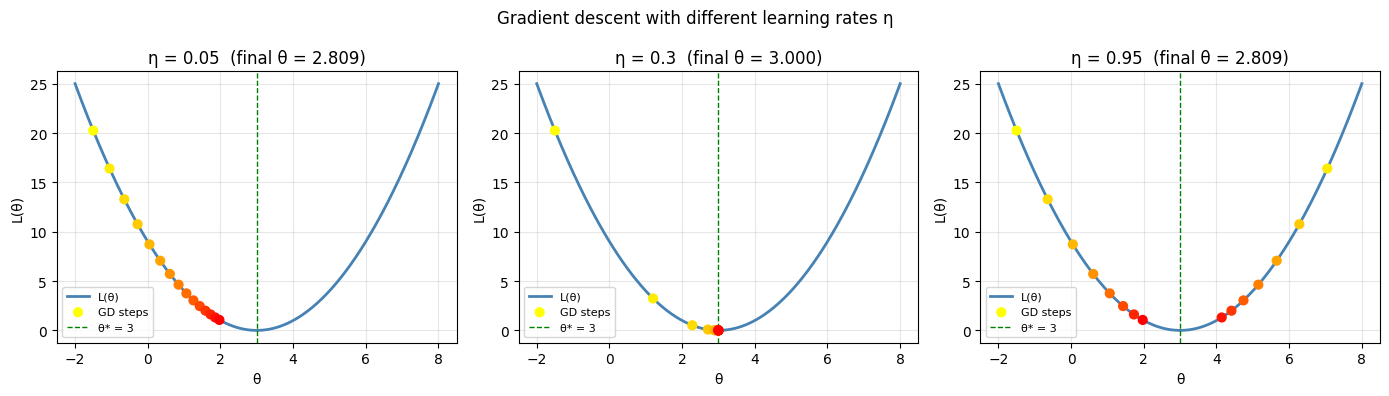


→ Middle plot (η=0.3): clean convergence. This is what happens inside every NN trainer.


In [2]:
# =============================================================================
# PART A — Gradient Descent from scratch (1D toy example)
# =============================================================================
print("=" * 60)
print("  PART A — Gradient Descent on a 1-parameter loss")
print("=" * 60)
print("""
Before neural networks, let's understand gradient descent on the
simplest possible loss: L(θ) = (θ - 3)²
The minimum is obviously at θ* = 3.
The gradient is dL/dθ = 2(θ - 3).
""")

def loss_1d(theta):   return (theta - 3.0) ** 2
def grad_1d(theta):   return 2.0 * (theta - 3.0)

learning_rates = [0.05, 0.3, 0.95]   # slow, good, too fast
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Gradient descent with different learning rates η", fontsize=12)

theta_plot = np.linspace(-2, 8, 300)

for ax, lr in zip(axes, learning_rates):
    theta = -1.5          # start far from minimum
    history = [theta]
    for _ in range(30):
        theta = theta - lr * grad_1d(theta)
        history.append(theta)

    ax.plot(theta_plot, loss_1d(theta_plot), "steelblue", lw=2, label="L(θ)")
    hist_arr = np.array(history[:15])    # first 15 steps
    ax.scatter(hist_arr, loss_1d(hist_arr),
               c=np.linspace(1, 0, len(hist_arr)), cmap="autumn",
               zorder=5, s=40, label="GD steps")
    ax.axvline(3, color="green", lw=1, linestyle="--", label="θ* = 3")
    ax.set_title(f"η = {lr}  (final θ = {history[-1]:.3f})")
    ax.set_xlabel("θ"); ax.set_ylabel("L(θ)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    print(f"η = {lr:4.2f}  →  after 30 steps, θ = {history[-1]:.4f}  "
          f"  {'converged!' if abs(history[-1]-3)<0.01 else 'diverged!' if abs(history[-1])>100 else 'slow...'}")

plt.tight_layout()
plt.savefig("./step3_gradient_descent.svg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()
print("\n→ Middle plot (η=0.3): clean convergence. This is what happens inside every NN trainer.")

In [3]:
# =============================================================================
# PART B — A non-linearly-separable GW dataset
# =============================================================================
print("\n" + "=" * 60)
print("  PART B — Ring-shaped signal region (non-linear problem)")
print("=" * 60)

# Physics motivation:
# Imagine we're searching for a specific class of compact binary merger.
# The signal only passes quality cuts if BOTH:
#   - SNR is in a moderate range (8-14): too low = undetected, too high = likely hardware glitch
#   - Chirp mass is in a specific range (15-45 M☉): our target population
# This creates an ANNULAR (ring/island) region in feature space —
# no straight line can separate it from the background.

N = 1200

# Background noise: uniform scatter everywhere
snr_bg   = rng.uniform(4, 20, N)
mass_bg  = rng.uniform(3, 70, N)

# Signal: concentrated in the ring/island
snr_sig  = rng.normal(11, 1.5, N)
mass_sig = rng.normal(28, 6.0, N)

# Only keep signal events that are "in the island"
# (simulate physical selection: events that truly look like our target)
is_ring = ((snr_sig - 11)**2 / 2.5**2 + (mass_sig - 28)**2 / 9**2) < 1.0
snr_sig  = snr_sig[is_ring][:300]
mass_sig = mass_sig[is_ring][:300]

# Also add a SECOND island at higher masses (two populations)
snr_sig2  = rng.normal(13, 1.2, N)
mass_sig2 = rng.normal(50, 5.0, N)
is_ring2  = ((snr_sig2-13)**2/2**2 + (mass_sig2-50)**2/8**2) < 1.0
snr_sig2  = snr_sig2[is_ring2][:150]
mass_sig2 = mass_sig2[is_ring2][:150]

snr_all  = np.concatenate([snr_bg[:600],  snr_sig,  snr_sig2])
mass_all = np.concatenate([mass_bg[:600], mass_sig, mass_sig2])
y_all    = np.concatenate([np.zeros(600), np.ones(len(snr_sig)+len(snr_sig2))])

X = np.column_stack([snr_all, mass_all])
print(f"Dataset: {(y_all==0).sum()} noise  |  {(y_all==1).sum()} signal events")
print("Signal forms two ISLANDS in (SNR, chirp mass) space — not linearly separable.\n")


  PART B — Ring-shaped signal region (non-linear problem)
Dataset: 600 noise  |  450 signal events
Signal forms two ISLANDS in (SNR, chirp mass) space — not linearly separable.



In this tutorial, we use a **simple neural network implementation** from **scikit-learn**.

For more details, see:
- The scikit-learn website: https://scikit-learn.org/stable/
- `MLPClassifier` documentation: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

In [5]:
# =============================================================================
# PART C — Logistic Regression vs Neural Network
# =============================================================================
print("=" * 60)
print("  PART C — Logistic regression vs. MLP")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_all, test_size=0.25, random_state=1, stratify=y_all)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

# ── Logistic regression (linear boundary) ────────────────────────────────────
lr_clf = LogisticRegression(max_iter=500, random_state=0)
lr_clf.fit(X_tr_s, y_train)
lr_auc = roc_auc_score(y_test, lr_clf.predict_proba(X_te_s)[:,1])

# ── Neural Network (non-linear boundary) ─────────────────────────────────────
# Architecture: 2 inputs → 32 neurons → 32 neurons → 1 output
# Activation: ReLU in hidden layers (another option to sigmoid — more common now)
# Optimiser: Adam (adaptive gradient descent — works better than plain GD)
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 32),   # two hidden layers, 32 neurons each
    activation="relu",              # ReLU: max(0, z) — simple but powerful
    solver="adam",                  # adaptive gradient descent
    max_iter=500,
    learning_rate_init=0.001,
    random_state=0,
    verbose=False
)
mlp.fit(X_tr_s, y_train)
mlp_auc = roc_auc_score(y_test, mlp.predict_proba(X_te_s)[:,1])

print(f"Logistic Regression  AUC = {lr_auc:.4f}")
print(f"Neural Network (MLP) AUC = {mlp_auc:.4f}")
print(f"\nImprovement: Δ AUC = +{mlp_auc - lr_auc:.4f}")
print("The NN finds the curved island boundaries; logistic regression can't.\n")

  PART C — Logistic regression vs. MLP
Logistic Regression  AUC = 0.5847
Neural Network (MLP) AUC = 0.9630

Improvement: Δ AUC = +0.3783
The NN finds the curved island boundaries; logistic regression can't.



In [6]:
# =============================================================================
# PART D — ReLU vs Sigmoid activation
# =============================================================================
print("=" * 60)
print("  PART D — Why ReLU instead of sigmoid in hidden layers?")
print("=" * 60)
print("""
SIGMOID σ(z) = 1/(1+e^{-z}):
  - Output ∈ (0,1), great for final output probability.
  - Problem: gradient ≈ 0 for large |z|  (VANISHING GRADIENT).
    Deep networks stop learning because ∂L/∂W → 0.

RELU f(z) = max(0, z):
  - Output ∈ [0, ∞), gradient is exactly 1 for z>0 (doesn't vanish!).
  - Fast to compute.
  - Standard choice for hidden layers in modern networks.
  - Still use sigmoid (or softmax) at the OUTPUT layer for probabilities.
""")

  PART D — Why ReLU instead of sigmoid in hidden layers?

SIGMOID σ(z) = 1/(1+e^{-z}):
  - Output ∈ (0,1), great for final output probability.
  - Problem: gradient ≈ 0 for large |z|  (VANISHING GRADIENT).
    Deep networks stop learning because ∂L/∂W → 0.

RELU f(z) = max(0, z):
  - Output ∈ [0, ∞), gradient is exactly 1 for z>0 (doesn't vanish!).
  - Fast to compute.
  - Standard choice for hidden layers in modern networks.
  - Still use sigmoid (or softmax) at the OUTPUT layer for probabilities.



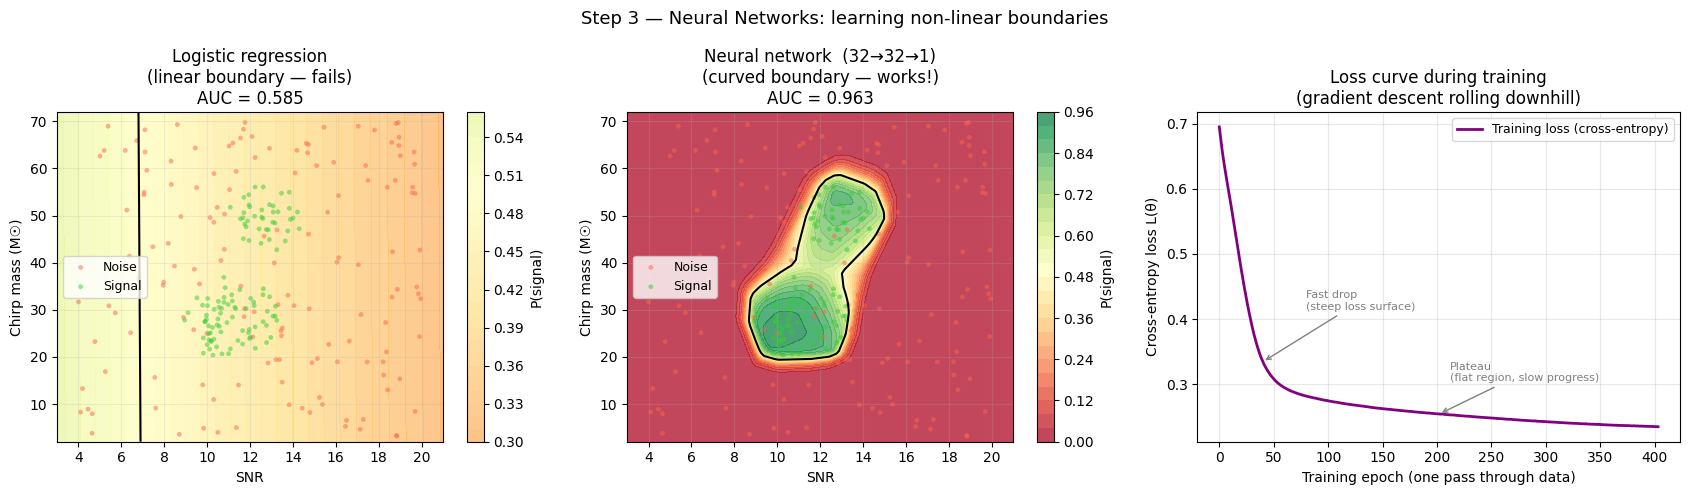

In [7]:
# =============================================================================
# PART E — Visualise everything
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Step 3 — Neural Networks: learning non-linear boundaries", fontsize=13)

xx, yy = np.meshgrid(np.linspace(3, 21, 280), np.linspace(2, 72, 280))
grid_raw = np.c_[xx.ravel(), yy.ravel()]
grid_s   = scaler.transform(grid_raw)

for ax, clf, title in zip(axes[:2],
                           [lr_clf, mlp],
                           ["Logistic regression\n(linear boundary — fails)",
                            "Neural network  (32→32→1)\n(curved boundary — works!)"]):
    Z = clf.predict_proba(grid_s)[:,1].reshape(xx.shape)
    cf = ax.contourf(xx, yy, Z, levels=30, cmap="RdYlGn", alpha=0.75, vmin=0, vmax=1)
    plt.colorbar(cf, ax=ax, label="P(signal)")
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.5)
    mask0 = (y_test == 0)
    mask1 = (y_test == 1)
    Xte_raw = scaler.inverse_transform(X_te_s)
    ax.scatter(Xte_raw[mask0,0], Xte_raw[mask0,1],
               c="tomato", s=12, alpha=0.5, label="Noise", edgecolors="none")
    ax.scatter(Xte_raw[mask1,0], Xte_raw[mask1,1],
               c="limegreen", s=12, alpha=0.5, label="Signal", edgecolors="none")
    ax.set_xlabel("SNR"); ax.set_ylabel("Chirp mass (M☉)")
    ax.set_title(title + f"\nAUC = {roc_auc_score(y_test, clf.predict_proba(X_te_s)[:,1]):.3f}")
    ax.legend(fontsize=9); ax.grid(alpha=0.2)

# ── Training loss curve ───────────────────────────────────────────────────────
ax3 = axes[2]
ax3.plot(mlp.loss_curve_, color="purple", lw=2, label="Training loss (cross-entropy)")
ax3.set_xlabel("Training epoch (one pass through data)")
ax3.set_ylabel("Cross-entropy loss L(θ)")
ax3.set_title("Loss curve during training\n(gradient descent rolling downhill)")
ax3.grid(alpha=0.3)

# Annotate phases
n = len(mlp.loss_curve_)
ax3.annotate("Fast drop\n(steep loss surface)",
             xy=(n//10, mlp.loss_curve_[n//10]),
             xytext=(n//5, mlp.loss_curve_[n//10]+0.08),
             fontsize=8, arrowprops=dict(arrowstyle="->", color="gray"), color="gray")
ax3.annotate("Plateau\n(flat region, slow progress)",
             xy=(n//2, mlp.loss_curve_[n//2]),
             xytext=(n//2+10, mlp.loss_curve_[n//2]+0.05),
             fontsize=8, arrowprops=dict(arrowstyle="->", color="gray"), color="gray")
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig("./step3_neural_network.svg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

In [8]:
# PART F — Counting parameters (making it concrete)
# =============================================================================
print("=" * 60)
print("  PART F — What's actually inside our network?")
print("=" * 60)

arch = [2, 32, 32, 1]
total = 0
for i in range(len(arch)-1):
    w_params = arch[i] * arch[i+1]
    b_params = arch[i+1]
    layer_total = w_params + b_params
    total += layer_total
    print(f"  Layer {i+1}:  {arch[i]} × {arch[i+1]} weights  +  {arch[i+1]} biases  =  {layer_total} params")
print(f"  {'─'*45}")
print(f"  Total parameters θ :  {total}")
print(f"\n  All {total} of these are updated by gradient descent every epoch.")
print(f"  For comparison: GPT-4 has ~1 000 000 000 000 (1 trillion) parameters.")
print(f"  Same principle, vastly more scale.\n")

  PART F — What's actually inside our network?
  Layer 1:  2 × 32 weights  +  32 biases  =  96 params
  Layer 2:  32 × 32 weights  +  32 biases  =  1056 params
  Layer 3:  32 × 1 weights  +  1 biases  =  33 params
  ─────────────────────────────────────────────
  Total parameters θ :  1185

  All 1185 of these are updated by gradient descent every epoch.
  For comparison: GPT-4 has ~1 000 000 000 000 (1 trillion) parameters.
  Same principle, vastly more scale.



In [9]:
# =============================================================================
# PART G — Key takeaways
# =============================================================================
print("=" * 60)
print("  KEY TAKEAWAYS — STEP 3")
print("=" * 60)
print("""
1. NEURAL NETWORKS stack layers: aₗ = σ(Wₗ · aₗ₋₁ + bₗ)
   Each layer transforms the representation non-linearly.
   Result: curved, complex decision boundaries.

2. GRADIENT DESCENT updates all parameters simultaneously:
        θ ← θ - η · ∂L/∂θ
   BACKPROP computes ∂L/∂θ efficiently via the chain rule.
   The LEARNING RATE η is a crucial hyperparameter.

3. RELU activation (max(0,z)) solves the vanishing gradient
   problem of sigmoid in deep hidden layers.
   Use sigmoid/softmax only at the output.

4. The LOSS CURVE is your training dashboard.
   Falling loss = the network is learning.
   Flat loss = stuck (bad η, bad architecture, bad data).
   Rising loss = overfitting (see Step 4 for regularisation).

5. PHYSICS USE CASES:
   - PyCBC / MLy GW event classification (curved χ²-SNR space)
   - Particle ID in collider detectors (non-linear PID variables)
   - Photometric redshift estimation (non-linear colour relations)
   - Pulsar vs. RFI in radio surveys (non-linear time-frequency features)

UP NEXT — STEP 4:
  "My network fits the training data perfectly but fails on new data."
  → OVERFITTING and how to cure it:
    dropout, regularisation, validation curves, early stopping.
  Then Step 5: what if the output is not a label but a
  FULL PROBABILITY DISTRIBUTION?  → density estimation → flows!
""")

  KEY TAKEAWAYS — STEP 3

1. NEURAL NETWORKS stack layers: aₗ = σ(Wₗ · aₗ₋₁ + bₗ)
   Each layer transforms the representation non-linearly.
   Result: curved, complex decision boundaries.

2. GRADIENT DESCENT updates all parameters simultaneously:
        θ ← θ - η · ∂L/∂θ
   BACKPROP computes ∂L/∂θ efficiently via the chain rule.
   The LEARNING RATE η is a crucial hyperparameter.

3. RELU activation (max(0,z)) solves the vanishing gradient
   problem of sigmoid in deep hidden layers.
   Use sigmoid/softmax only at the output.

4. The LOSS CURVE is your training dashboard.
   Falling loss = the network is learning.
   Flat loss = stuck (bad η, bad architecture, bad data).
   Rising loss = overfitting (see Step 4 for regularisation).

5. PHYSICS USE CASES:
   - PyCBC / MLy GW event classification (curved χ²-SNR space)
   - Particle ID in collider detectors (non-linear PID variables)
   - Photometric redshift estimation (non-linear colour relations)
   - Pulsar vs. RFI in radio surveys 